In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

Array dimensions:  (668, 500, 3)
Data type:  uint8
Size:  1.002  megabytes


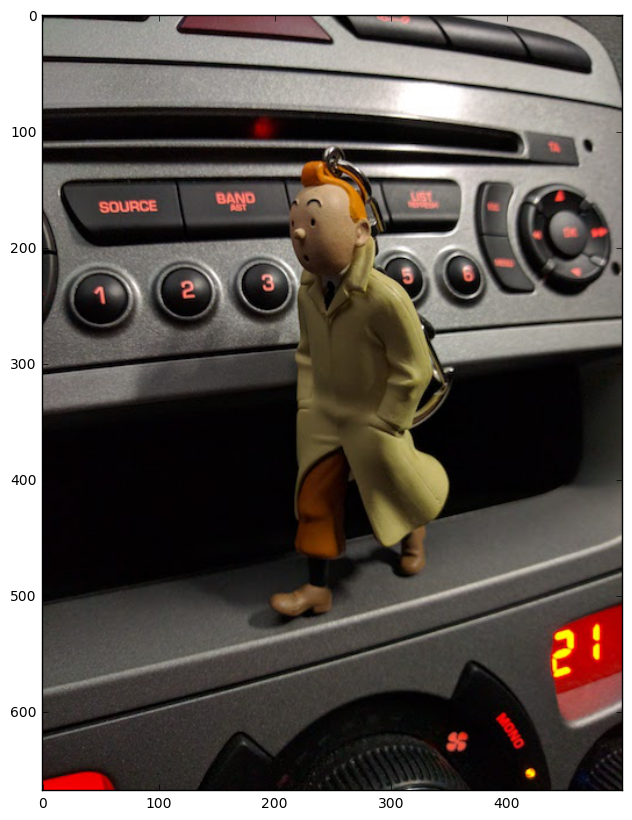

In [2]:
img = mpimg.imread('TinTin.jpg')
plt.figure(figsize=(7.5,10)) 
plt.imshow(img)

print("Array dimensions: ", img.shape)
print("Data type: ", img.dtype)
print("Size: ", img.nbytes/1000000, " megabytes")

Array dimensions:  (668, 500)
Data type:  uint8
Size:  0.334  megabytes


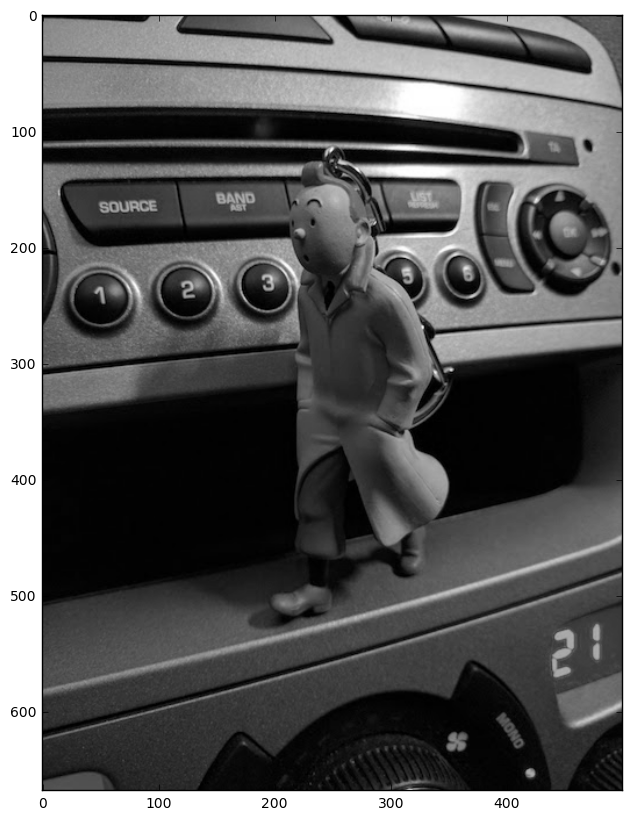

In [3]:
imggray = np.mean(img,2).astype("uint8")
plt.figure(figsize=(7.5,10))
plt.imshow(imggray,cmap="gray");

oldSize = imggray.nbytes/1000000

print("Array dimensions: ", imggray.shape)
print("Data type: ", imggray.dtype)
print("Size: ", oldSize, " megabytes")

SINGULAR VALUES
1st:  46053
2nd:  13189
30th:  1311
60th:  654


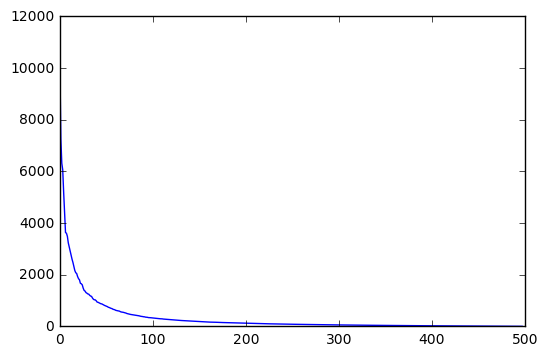

In [4]:
U, sigma, V = np.linalg.svd(imggray)

plt.plot(sigma[2:])
#plt.plot(sigma)

print("SINGULAR VALUES")
print("1st: ", sigma[0].astype(int))
print("2nd: ", sigma[1].astype(int))
print("30th: ", sigma[30].astype(int))
print("60th: ", sigma[60].astype(int))

Expected compression:  0.105
Actual compression:  0.8399999999999999
SVD data type:  float64


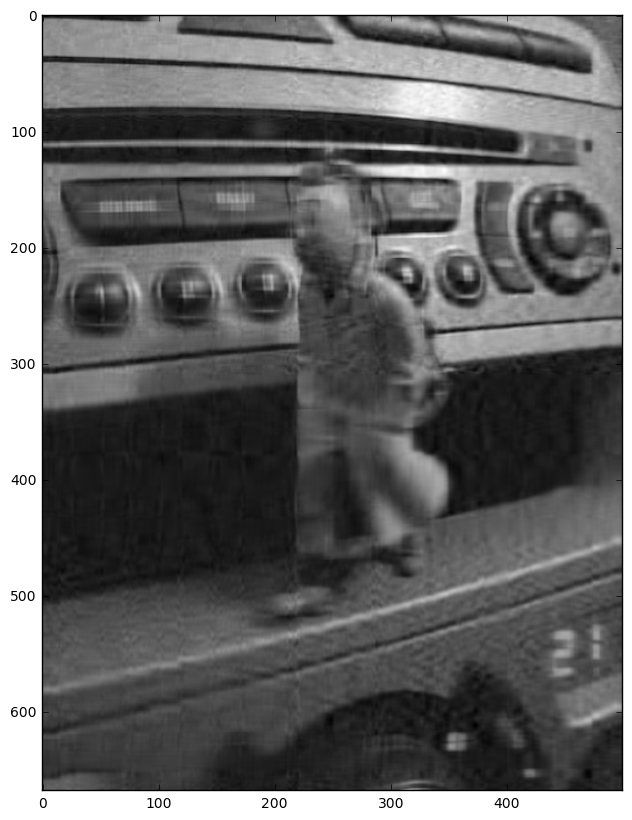

In [5]:
n = 30
reconstimg = np.matrix(U[:, :n]) * np.diag(sigma[:n]) * np.matrix(V[:n, :])
plt.figure(figsize=(7.5,10))
plt.imshow(reconstimg,cmap="gray");

s = imggray.shape
expComp = n * (1+s[0]+s[1]) / (s[0]*s[1])
newSize = (U[:,:n].nbytes + sigma[:n].nbytes + V[:n,:].nbytes)/1000000

print( "Expected compression: ", expComp)
print( "Actual compression: ", newSize/oldSize )
print( "SVD data type: ", U[:,:n].dtype )

Compression:  0.8399999999999999
SVD data type:  float32


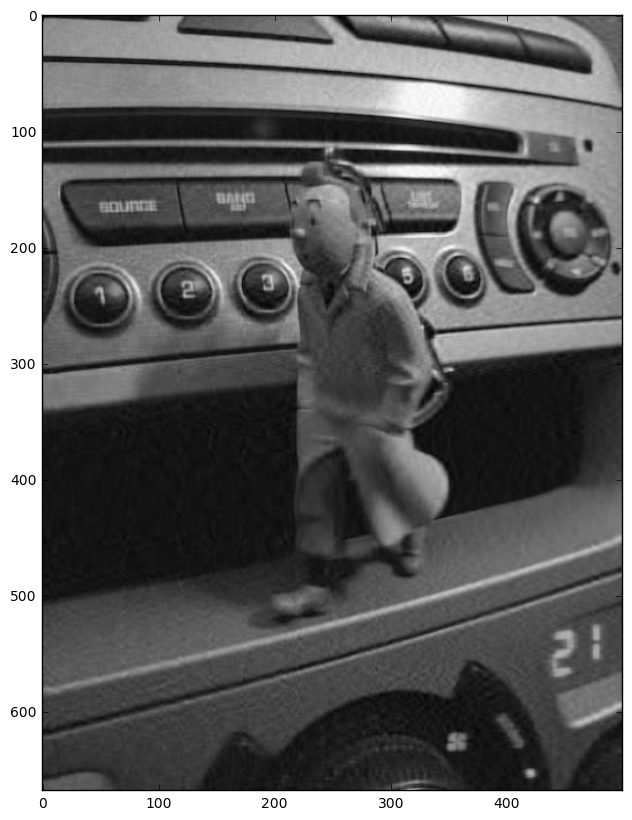

In [6]:
U = U.astype(np.float32)
sigma = sigma.astype(np.float32)
V = V.astype(np.float32)

n = 60
reconstimg = np.matrix(U[:, :n]) * np.diag(sigma[:n]) * np.matrix(V[:n, :])
plt.figure(figsize=(7.5,10))
plt.imshow(reconstimg,cmap="gray");

newSize = (U[:,:n].nbytes + sigma[:n].nbytes + V[:n,:].nbytes)/1000000

print( "Compression: ", newSize/oldSize )
print( "SVD data type: ", U[:,:n].dtype )